<a href="https://colab.research.google.com/github/Zahraalavi2415/Zahraalavi2415.github.io/blob/main/Monte_Carlo_how_to_measure_anything_book's_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

----- Monte Carlo Results -----
Number of simulations: 10000
Mean annual savings: $585,784.31
Median annual savings: $574,386.73
Minimum annual savings: $0.00
Maximum annual savings: $1,534,707.38

Probability of breaking even or better: 83.37%
Probability of loss (savings < $400,000): 16.63%
Probability of losing more than $100,000: 5.77%


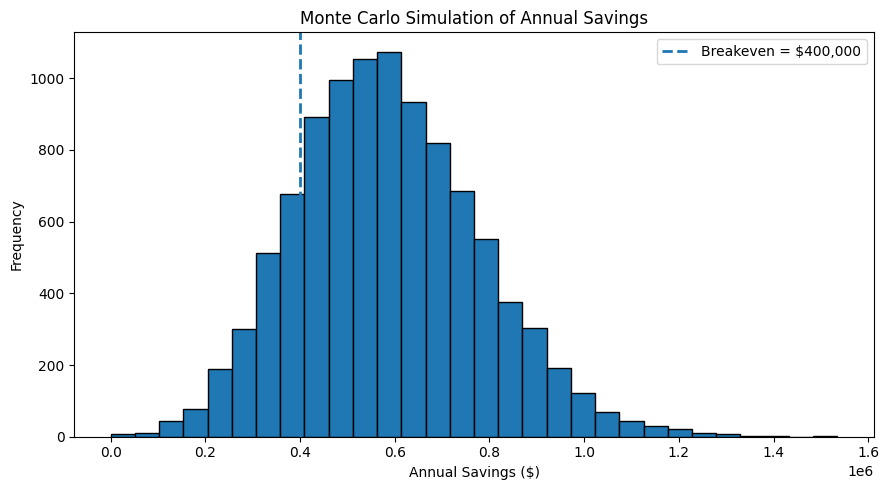

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) تنظیمات اولیه
# -----------------------------
np.random.seed(42)   # برای تکرارپذیری
n_sim = 10000        # تعداد سناریوهای مونت‌کارلو
breakeven = 400000   # هزینه اجاره سالانه

# -----------------------------
# 2) تابع کمکی:
# تبدیل بازه 90% CI به پارامترهای نرمال
# mean = midpoint
# std = (upper-lower)/3.29
# -----------------------------
def normal_from_90ci(lower, upper, size):
    mean = (lower + upper) / 2
    std = (upper - lower) / 3.29
    return np.random.normal(loc=mean, scale=std, size=size)

# -----------------------------
# 3) تولید ورودی‌های تصادفی
# -----------------------------
# Maintenance savings (دلار به ازای هر واحد)
MS = normal_from_90ci(10, 20, n_sim)

# Labor savings (دلار به ازای هر واحد)
LS = normal_from_90ci(-2, 8, n_sim)

# Raw materials savings (دلار به ازای هر واحد)
RMS = normal_from_90ci(3, 9, n_sim)

# Production level normal (واحد در سال)
PL_normal = normal_from_90ci(15000, 35000, n_sim)

# -----------------------------
# 4) رویداد از دست دادن قرارداد
# Contract Loss ~ Bernoulli(p=0.10)
# -----------------------------
contract_loss = np.random.binomial(n=1, p=0.10, size=n_sim)

# Months Remaining ~ Uniform(0, 12)
months_remaining = np.random.uniform(0, 12, size=n_sim)

# -----------------------------
# 5) تنظیم سطح تولید بعد از از دست دادن قرارداد
# فرمول کتاب:
# PL_new = PL_normal - 1000 * (Contract Loss * Months Remaining)
# -----------------------------
PL_new = PL_normal - 1000 * (contract_loss * months_remaining)

# برای اطمینان: تولید منفی نشود
PL_new = np.maximum(PL_new, 0)

# -----------------------------
# 6) محاسبه صرفه‌جویی سالانه
# Annual Savings = (MS + LS + RMS) * PL_new
# -----------------------------
annual_savings = (MS + LS + RMS) * PL_new

# سود/زیان خالص نسبت به breakeven
net_result = annual_savings - breakeven

# -----------------------------
# 7) شاخص‌های ریسک
# -----------------------------
p_break_even_met = np.mean(annual_savings >= breakeven)
p_loss = np.mean(annual_savings < breakeven)
p_big_loss = np.mean(net_result < -100000)   # بیش از 100 هزار دلار ضرر

print("----- Monte Carlo Results -----")
print(f"Number of simulations: {n_sim}")
print(f"Mean annual savings: ${np.mean(annual_savings):,.2f}")
print(f"Median annual savings: ${np.median(annual_savings):,.2f}")
print(f"Minimum annual savings: ${np.min(annual_savings):,.2f}")
print(f"Maximum annual savings: ${np.max(annual_savings):,.2f}")
print()
print(f"Probability of breaking even or better: {p_break_even_met:.2%}")
print(f"Probability of loss (savings < $400,000): {p_loss:.2%}")
print(f"Probability of losing more than $100,000: {p_big_loss:.2%}")

# -----------------------------
# 8) هیستوگرام خروجی
# -----------------------------
plt.figure(figsize=(9, 5))
plt.hist(annual_savings, bins=30, edgecolor="black")
plt.axvline(breakeven, linestyle="--", linewidth=2, label="Breakeven = $400,000")
plt.xlabel("Annual Savings ($)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Simulation of Annual Savings")
plt.legend()
plt.tight_layout()
plt.show()